# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df = pd.read_csv('student-mat.csv', sep=';')
print("Dataset Preview:")
print(df.head())

Dataset Preview:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [ ]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
df['performance'] = df['G3'].apply(lambda x: 1 if x > 10 else 0)

In [ ]:
df = df.drop('G3', axis=1)

In [ ]:
X = df.drop('performance', axis=1)
y = df['performance']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

In [ ]:
print("🔵 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

🔵 Logistic Regression Accuracy: 0.8987341772151899
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.90      0.90      0.90        41

    accuracy                           0.90        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.90      0.90      0.90        79



In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
print("🟢 KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

🟢 KNN Accuracy: 0.7848101265822784
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        38
           1       0.77      0.83      0.80        41

    accuracy                           0.78        79
   macro avg       0.79      0.78      0.78        79
weighted avg       0.79      0.78      0.78        79



In [ ]:
logreg_cv = cross_val_score(logreg, X_scaled, y, cv=5)
knn_cv= cross_val_score(knn, X_scaled, y, cv=5)

In [ ]:
print("🔵 Logistic Regression CV Accuracy:", logreg_cv.mean())
print("🟢 KNN CV Accuracy:", knn_cv.mean())

🔵 Logistic Regression CV Accuracy: 0.8936708860759495
🟢 KNN CV Accuracy: 0.7746835443037975


#Visual Representation

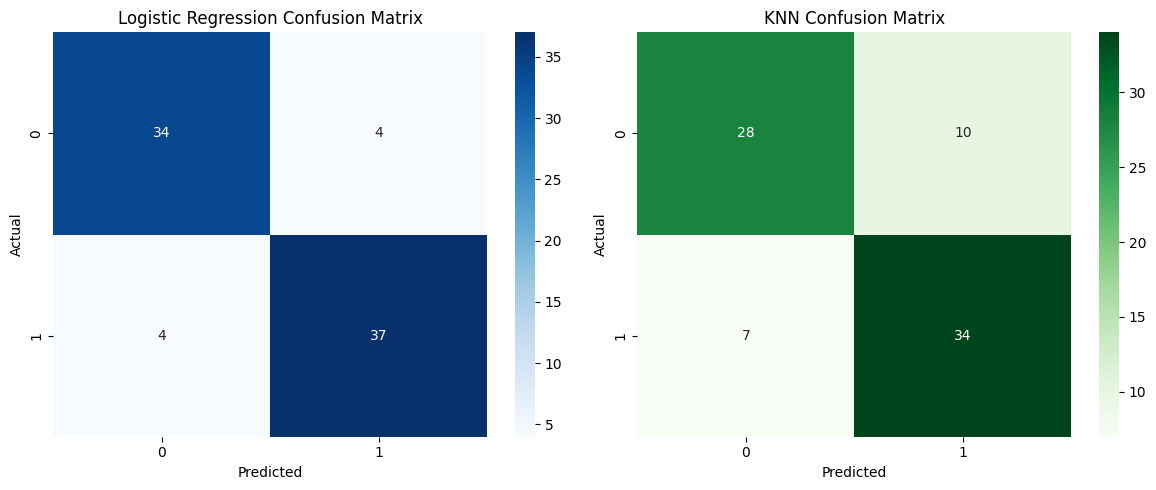

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title('Logistic Regression Confusion Matrix')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens', ax=axs[1])
axs[1].set_title('KNN Confusion Matrix')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
models = ['Logistic Regression', 'KNN']
accuracy = [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_knn)]

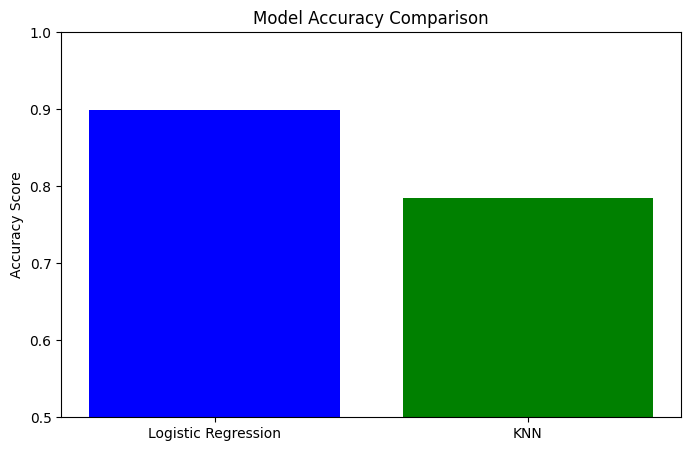

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(models, accuracy, color=['blue', 'green'])
plt.ylim(0.5, 1)
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")
plt.show()

<ipython-input-75-bad63f014c92>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='performance', data=df, palette='pastel', edgecolor='black')
<ipython-input-75-bad63f014c92>:27: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


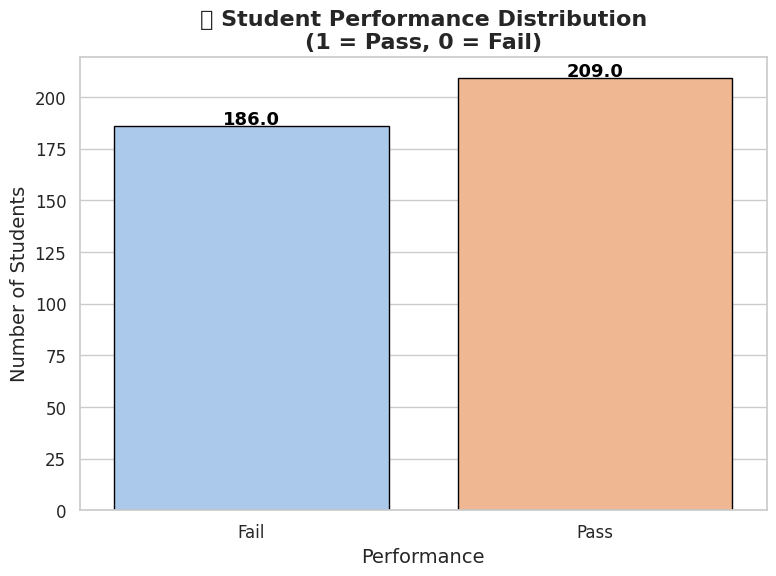

In [ ]:
# Set the style, palette, and font size for better aesthetics
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

# 1️⃣ Performance Distribution
plt.figure(figsize=(8, 6))

# Plotting the countplot with better styling and additional annotations
ax = sns.countplot(x='performance', data=df, palette='pastel', edgecolor='black')

# Adding Title and Labels with more details
plt.title('📊 Student Performance Distribution\n(1 = Pass, 0 = Fail)', fontsize=16, fontweight='bold')
plt.xlabel('Performance', fontsize=14)
plt.ylabel('Number of Students', fontsize=14)

# Customizing X-ticks and Y-ticks for clearer understanding
plt.xticks([0, 1], ['Fail', 'Pass'], fontsize=12)
plt.yticks(fontsize=12)

# Adding count labels on top of each bar for better clarity
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=13, color='black', fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

# Tight layout for better spacing
plt.tight_layout()

# Show plot
plt.show()


<ipython-input-71-06d832c0e45a>:16: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


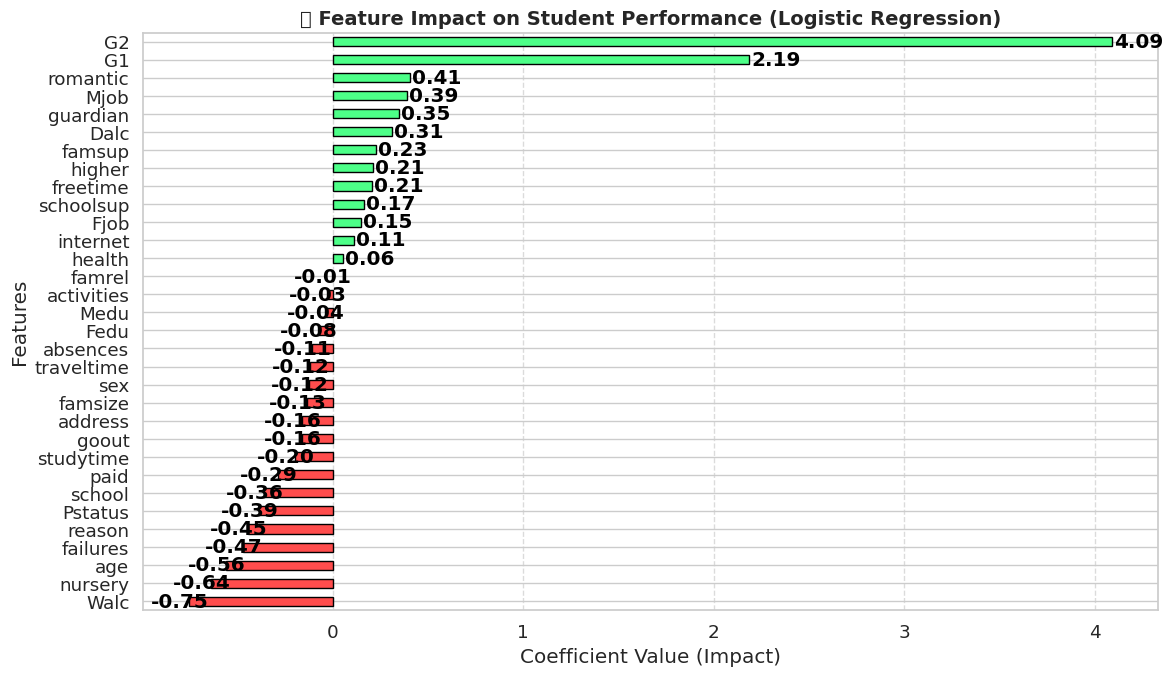

In [ ]:
importance = logreg.coef_[0]
feature_importance = pd.Series(importance, index=X.columns).sort_values()

colors = ['#ff4d4d' if val < 0 else '#4dff88' for val in feature_importance]

plt.figure(figsize=(12, 7))
bars = feature_importance.plot(kind='barh', color=colors, edgecolor='black')

for i, v in enumerate(feature_importance):
    plt.text(v + 0.01 if v > 0 else v - 0.2, i, f'{v:.2f}', color='black', va='center', fontweight='bold')

plt.title('📊 Feature Impact on Student Performance (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (Impact)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<ipython-input-73-321df1ae653a>:30: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


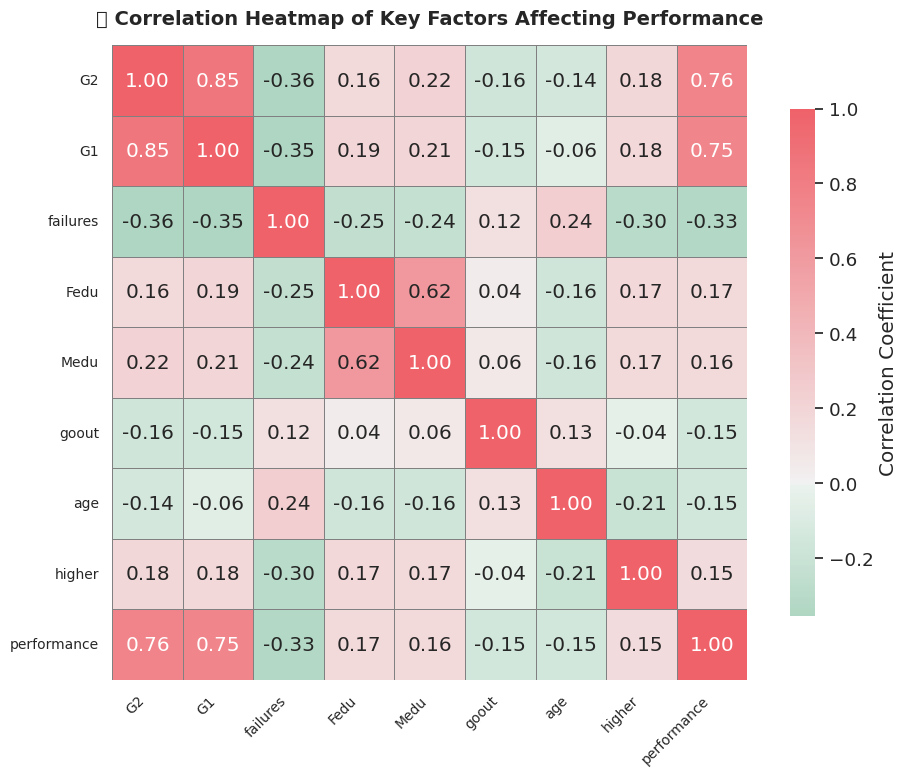

In [ ]:
# Get top correlated features with 'performance'
correlation_matrix = df.corr()
top_corr = correlation_matrix['performance'].abs().sort_values(ascending=False)[1:9]  # Skip 'performance' itself
top_features = top_corr.index.tolist()

# Filtered correlation matrix
selected_corr = df[top_features + ['performance']].corr()

# Set up the plot
plt.figure(figsize=(10, 8))
cmap = sns.diverging_palette(145, 10, s=80, l=60, as_cmap=True)  # green to red

# Plot heatmap
sns.heatmap(
    selected_corr,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    linewidths=0.6,
    linecolor='gray',
    square=True,
    cbar_kws={"shrink": .8, "label": "Correlation Coefficient"}
)

# Title and layout tweaks
plt.title('💡 Correlation Heatmap of Key Factors Affecting Performance', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


#User Input Comparison

In [ ]:
def user_input():
  print("Please enter the following information:")
  data = {
        'school': input("School (GP or MS): "),
        'sex': input("Sex (M or F): "),
        'age': int(input("Age (e.g., 17): ")),
        'address': input("Address (U = urban, R = rural): "),
        'famsize': input("Family size (GT3 = >3, LE3 = <=3): "),
        'Pstatus': input("Parent's status (T = together, A = apart): "),
        'Medu': int(input("Mother's education (0 to 4): ")),
        'Fedu': int(input("Father's education (0 to 4): ")),
        'Mjob': input("Mother's job (teacher, health, services, at_home, other): "),
        'Fjob': input("Father's job (teacher, health, services, at_home, other): "),
        'reason': input("Reason for choosing school (home, reputation, course, other): "),
        'guardian': input("Guardian (mother, father, other): "),
        'traveltime': int(input("Travel time (1 to 4): ")),
        'studytime': int(input("Weekly study time (1 to 4): ")),
        'failures': int(input("Past class failures (0 to 3): ")),
        'schoolsup': input("Extra educational support? (yes or no): "),
        'famsup': input("Family support? (yes or no): "),
        'paid': input("Extra paid classes? (yes or no): "),
        'activities': input("Extra-curricular activities? (yes or no): "),
        'nursery': input("Attended nursery school? (yes or no): "),
        'higher': input("Wants higher education? (yes or no): "),
        'internet': input("Internet access at home? (yes or no): "),
        'romantic': input("In a romantic relationship? (yes or no): "),
        'famrel': int(input("Family relationship quality (1 to 5): ")),
        'freetime': int(input("Free time after school (1 to 5): ")),
        'goout': int(input("Going out with friends (1 to 5): ")),
        'Dalc': int(input("Workday alcohol consumption (1 to 5): ")),
        'Walc': int(input("Weekend alcohol consumption (1 to 5): ")),
        'health': int(input("Current health status (1 to 5): ")),
        'absences': int(input("Number of school absences: ")),
        'G1': int(input("First period grade (0-20): ")),
        'G2': int(input("Second period grade (0-20): "))
        }
  return pd.DataFrame([data])

In [ ]:
user_df = user_input()
user_encoded = pd.get_dummies(user_df)
user_encoded = user_encoded.reindex(columns=X.columns, fill_value=0)
user_scaled = scaler.transform(user_encoded)

pred_log = logreg.predict(user_scaled)[0]
pred_knn = knn.predict(user_scaled)[0]

print("\n📢 Prediction Results:")
print(f"🔍 Logistic Regression: {'✅ PASS' if pred_log == 1 else '❌ FAIL'}")
print(f"🔍 K-Nearest Neighbors: {'✅ PASS' if pred_knn == 1 else '❌ FAIL'}")

Please enter the following information:
School (GP or MS): ms
Sex (M or F): f
Age (e.g., 17): 18
Address (U = urban, R = rural): u
Family size (GT3 = >3, LE3 = <=3): le3
Parent's status (T = together, A = apart): t
Mother's education (0 to 4): 4
Father's education (0 to 4): 4
Mother's job (teacher, health, services, at_home, other): services
Father's job (teacher, health, services, at_home, other): health
Reason for choosing school (home, reputation, course, other): reputation
Guardian (mother, father, other): father
Travel time (1 to 4): 1
Weekly study time (1 to 4): 4
Past class failures (0 to 3): 3
Extra educational support? (yes or no): yes
Family support? (yes or no): yes
Extra paid classes? (yes or no): yes
Extra-curricular activities? (yes or no): yes
Attended nursery school? (yes or no): yes
Wants higher education? (yes or no): yes
Internet access at home? (yes or no): yes
In a romantic relationship? (yes or no): yes
Family relationship quality (1 to 5): 5
Free time after schoo